# Faz 0.1 — Musical Instruments Dataset Keşfi

Bu notebook'ta:
1. Amazon Reviews 2023 dataset'inden Musical Instruments kategorisini yüklüyoruz
2. Boyutuna, şemasına, dağılımlarına bakıyoruz
3. Sampling kararı için bilgi topluyoruz (bu notebook'ta SAMPLE YAPMIYORUZ, sadece keşif)

**Önemli:** Bu notebook için GPU'ya gerek yok. `Runtime → Change runtime type → CPU` yeterli.

**Tahmini süre:** 10-15 dakika (büyük kısmı veri indirme)

## 1. Kurulum

In [3]:
# Gerekli paketler
!pip install -q "datasets==2.19.2" pandas matplotlib seaborn huggingface_hub

In [4]:
# Google Drive bağla
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/data-mining-hw'
os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/data', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/embeddings', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/figures', exist_ok=True)
print(f'Proje klasörü hazır: {PROJECT_DIR}')
print('İçerik:', os.listdir(PROJECT_DIR))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Proje klasörü hazır: /content/drive/MyDrive/data-mining-hw
İçerik: ['data', 'embeddings', 'figures']


In [5]:
# HF token
from google.colab import userdata
from huggingface_hub import login

try:
    token = userdata.get('HF_TOKEN')
    login(token=token)
    print('HF login: OK ✓')
except Exception as e:
    print(f'HF login problemi: {e}')

HF login: OK ✓


## 2. Review'leri Yükle

`raw_review_Musical_Instruments` config'i Musical Instruments kategorisindeki tüm yorumları içerir.

**Şema:** `rating, title, text, images, asin, parent_asin, user_id, timestamp, helpful_vote, verified_purchase`

In [1]:
from datasets import load_dataset
import time

t0 = time.time()
print('Reviews indiriliyor...')
ds_reviews = load_dataset(
    'McAuley-Lab/Amazon-Reviews-2023',
    'raw_review_Musical_Instruments',
    split='full',
    trust_remote_code=True
)
print(f'✓ Tamam ({time.time()-t0:.1f} sn)')
print(f'Toplam review: {len(ds_reviews):,}')
print(f'Sütunlar: {ds_reviews.column_names}')

Reviews indiriliyor...


Generating full split: 0 examples [00:00, ? examples/s]

✓ Tamam (165.9 sn)
Toplam review: 3,017,439
Sütunlar: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']


In [2]:
# Bir review'a bak
print('=== ÖRNEK REVIEW ===')
sample = ds_reviews[0]
for k, v in sample.items():
    if isinstance(v, str) and len(v) > 200:
        print(f'{k}: {v[:200]}...')
    else:
        print(f'{k}: {v}')

=== ÖRNEK REVIEW ===
rating: 5.0
title: Five Stars
text: Great headphones, comfortable and sound is good. No complaints. I would buy again.
images: []
asin: B003LPTAYI
parent_asin: B003LPTAYI
user_id: AGKASBHYZPGTEPO6LWZPVJWB2BVA
timestamp: 1452650586000
helpful_vote: 0
verified_purchase: True


## 3. Metadata'yı Yükle

`raw_meta_Musical_Instruments` config'i ürün bilgilerini içerir.

**Şema:** `main_category, title, average_rating, rating_number, features, description, price, images, videos, store, categories, details, parent_asin, bought_together, ...`

In [6]:
t0 = time.time()
print('Metadata indiriliyor...')
ds_meta = load_dataset(
    'McAuley-Lab/Amazon-Reviews-2023',
    'raw_meta_Musical_Instruments',
    split='full',
    trust_remote_code=True
)
print(f'✓ Tamam ({time.time()-t0:.1f} sn)')
print(f'Toplam ürün: {len(ds_meta):,}')
print(f'Sütunlar: {ds_meta.column_names}')

Metadata indiriliyor...


Generating full split:   0%|          | 0/213593 [00:00<?, ? examples/s]

✓ Tamam (89.2 sn)
Toplam ürün: 213,593
Sütunlar: ['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together', 'subtitle', 'author']


In [7]:
# Bir ürüne bak
print('=== ÖRNEK ÜRÜN ===')
sample = ds_meta[0]
for k, v in sample.items():
    if isinstance(v, str) and len(v) > 200:
        print(f'{k}: {v[:200]}...')
    elif isinstance(v, list):
        print(f'{k}: [list, {len(v)} eleman] ilk 2: {v[:2]}')
    elif isinstance(v, dict):
        print(f'{k}: [dict, keys: {list(v.keys())}]')
    else:
        print(f'{k}: {v}')

=== ÖRNEK ÜRÜN ===
main_category: Musical Instruments
title: Pearl Export Lacquer EXL725S/C249 5-Piece New Fusion Drum Set with Hardware, Honey Amber
average_rating: 4.2
rating_number: 22
features: [list, 5 eleman] ilk 2: ['Item may ship in more than one box and may arrive separately', '(22x18, 10x7, 12x8, 16x16, 14x5.5)']
description: [list, 1 eleman] ilk 2: ["Introducing the best selling drum set of all time... Export Series returns and this time with a lacquer finish. EXL Export Lacquer Series incorporates Pearl's S.S.T. Superior Shell Technology, Opti-Loc tom mounts, all-new 830 Series Hardware with a P-930 Pedal, and a choice of three amazing stocking finishes."]
price: None
images: [dict, keys: ['hi_res', 'large', 'thumb', 'variant']]
videos: [dict, keys: ['title', 'url', 'user_id']]
store: Pearl
categories: [list, 4 eleman] ilk 2: ['Musical Instruments', 'Drums & Percussion']
details: {"Item Weight": "33 pounds", "Product Dimensions": "22 x 22 x 20 inches", "Item model number": 

## 4. Hafif Pandas DataFrame (sadece numerik/ID sütunlar)

Text/image gibi ağır sütunları henüz yüklemiyoruz — Colab free RAM'ini koruyalım.
Onlar ileride sampling sonrası lazım olacak.

In [10]:
import pandas as pd
import numpy as np

# Review'lerden sadece hafif sütunlar
print('Reviews DataFrame oluşturuluyor...')
df_reviews = pd.DataFrame({
    'user_id': ds_reviews['user_id'],
    'parent_asin': ds_reviews['parent_asin'],
    'rating': ds_reviews['rating'],
    'timestamp': ds_reviews['timestamp'],
    'helpful_vote': ds_reviews['helpful_vote'],
    'verified_purchase': ds_reviews['verified_purchase'],
})
print(f'Shape: {df_reviews.shape}')
print(f'Bellek: {df_reviews.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Reviews DataFrame oluşturuluyor...
Shape: (3017439, 6)
Bellek: 485.8 MB


In [11]:
# Metadata DataFrame (yine hafif sütunlar)
print('Metadata DataFrame oluşturuluyor...')

# images alanı dict, görseli olup olmadığını flag olarak çekelim
def has_large_image(img):
    try:
        return isinstance(img, dict) and len(img.get('large', [])) > 0
    except:
        return False

def desc_length(desc):
    if isinstance(desc, list):
        return sum(len(d) for d in desc if isinstance(d, str))
    return len(str(desc)) if desc else 0

df_meta = pd.DataFrame({
    'parent_asin': ds_meta['parent_asin'],
    'title': ds_meta['title'],
    'main_category': ds_meta['main_category'],
    'average_rating': ds_meta['average_rating'],
    'rating_number': ds_meta['rating_number'],
    'price': ds_meta['price'],
    'store': ds_meta['store'],
})
df_meta['has_image'] = [has_large_image(img) for img in ds_meta['images']]
df_meta['desc_len'] = [desc_length(d) for d in ds_meta['description']]
df_meta['has_bought_together'] = [bt is not None and len(bt) > 0 if isinstance(bt, list) else (bt is not None) for bt in ds_meta['bought_together']]

print(f'Shape: {df_meta.shape}')
print(f'Bellek: {df_meta.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Metadata DataFrame oluşturuluyor...
Shape: (213593, 10)
Bellek: 86.4 MB


## 5. Temel İstatistikler

In [12]:
print('=== GENEL ÖZET ===\n')
print(f'Toplam review: {len(df_reviews):,}')
print(f'Tekil kullanıcı: {df_reviews["user_id"].nunique():,}')
print(f'Tekil ürün (review\'lerdeki): {df_reviews["parent_asin"].nunique():,}')
print(f'Toplam ürün (metadata): {len(df_meta):,}')
print(f'Verified purchase oranı: {df_reviews["verified_purchase"].mean()*100:.1f}%')
print(f'Ortalama rating: {df_reviews["rating"].mean():.2f}')
print(f'Ortalama helpful vote: {df_reviews["helpful_vote"].mean():.2f}')

=== GENEL ÖZET ===

Toplam review: 3,017,439
Tekil kullanıcı: 1,762,679
Tekil ürün (review'lerdeki): 213,571
Toplam ürün (metadata): 213,593
Verified purchase oranı: 92.1%
Ortalama rating: 4.26
Ortalama helpful vote: 1.14


In [13]:
# Tarih aralığı
df_reviews['date'] = pd.to_datetime(df_reviews['timestamp'], unit='ms')
print(f'Tarih aralığı: {df_reviews["date"].min().date()} → {df_reviews["date"].max().date()}')
print(f'\nYıllara göre review sayısı:')
print(df_reviews['date'].dt.year.value_counts().sort_index())

Tarih aralığı: 1999-08-26 → 2023-09-12

Yıllara göre review sayısı:
date
1999         2
2000        29
2001        46
2002        70
2003       186
2004       425
2005       783
2006      1211
2007      3035
2008      4379
2009      7605
2010     17009
2011     32394
2012     51822
2013    116884
2014    174144
2015    241910
2016    271023
2017    261260
2018    273353
2019    346548
2020    390665
2021    390310
2022    301080
2023    131266
Name: count, dtype: int64


In [14]:
# Rating dağılımı
print('=== RATING DAĞILIMI ===')
rating_dist = df_reviews['rating'].value_counts().sort_index()
print(rating_dist)
print(f'\nNegatif (1-2) review oranı: {(df_reviews["rating"] <= 2).mean()*100:.1f}%')
print(f'Pozitif (4-5) review oranı: {(df_reviews["rating"] >= 4).mean()*100:.1f}%')

=== RATING DAĞILIMI ===
rating
1.0     264352
2.0     131441
3.0     197131
4.0     400387
5.0    2024128
Name: count, dtype: int64

Negatif (1-2) review oranı: 13.1%
Pozitif (4-5) review oranı: 80.4%


In [15]:
# Kullanıcı aktivitesi (cold-start ve sampling için kritik)
user_counts = df_reviews['user_id'].value_counts()
print('=== KULLANICI AKTİVİTESİ ===')
print(f'Ortalama review/kullanıcı: {user_counts.mean():.2f}')
print(f'Medyan: {user_counts.median()}')
print(f'\nThreshold\'a göre kullanıcı sayısı:')
for k in [1, 2, 3, 5, 10, 20, 50, 100]:
    cnt = (user_counts >= k).sum()
    pct = cnt / len(user_counts) * 100
    print(f'  >= {k:>3} review: {cnt:>10,} kullanıcı ({pct:.1f}%)')

=== KULLANICI AKTİVİTESİ ===
Ortalama review/kullanıcı: 1.71
Medyan: 1.0

Threshold'a göre kullanıcı sayısı:
  >=   1 review:  1,762,679 kullanıcı (100.0%)
  >=   2 review:    458,433 kullanıcı (26.0%)
  >=   3 review:    214,135 kullanıcı (12.1%)
  >=   5 review:     84,574 kullanıcı (4.8%)
  >=  10 review:     23,286 kullanıcı (1.3%)
  >=  20 review:      5,547 kullanıcı (0.3%)
  >=  50 review:        546 kullanıcı (0.0%)
  >= 100 review:         78 kullanıcı (0.0%)


In [16]:
# Ürün popülerliği
item_counts = df_reviews['parent_asin'].value_counts()
print('=== ÜRÜN POPÜLERLİĞİ ===')
print(f'Ortalama review/ürün: {item_counts.mean():.2f}')
print(f'Medyan: {item_counts.median()}')
print(f'\nThreshold\'a göre ürün sayısı:')
for k in [1, 2, 3, 5, 10, 20, 50, 100]:
    cnt = (item_counts >= k).sum()
    pct = cnt / len(item_counts) * 100
    print(f'  >= {k:>3} review: {cnt:>10,} ürün ({pct:.1f}%)')

=== ÜRÜN POPÜLERLİĞİ ===
Ortalama review/ürün: 14.13
Medyan: 2.0

Threshold'a göre ürün sayısı:
  >=   1 review:    213,571 ürün (100.0%)
  >=   2 review:    134,922 ürün (63.2%)
  >=   3 review:    102,066 ürün (47.8%)
  >=   5 review:     71,218 ürün (33.3%)
  >=  10 review:     42,363 ürün (19.8%)
  >=  20 review:     23,840 ürün (11.2%)
  >=  50 review:     10,163 ürün (4.8%)
  >= 100 review:      4,846 ürün (2.3%)


In [17]:
# Metadata zenginliği (multimodal feature'lar için kritik)
print('=== METADATA ZENGİNLİĞİ ===')
print(f'Görseli olan ürün: {df_meta["has_image"].sum():,} ({df_meta["has_image"].mean()*100:.1f}%)')
print(f'Açıklaması olan ürün: {(df_meta["desc_len"] > 0).sum():,} ({(df_meta["desc_len"] > 0).mean()*100:.1f}%)')
print(f'Ortalama açıklama uzunluğu: {df_meta["desc_len"].mean():.0f} karakter')

# Fiyat - string olabilir
def parse_price(p):
    if p in [None, 'None', '', 'nan']: return None
    try:
        return float(str(p).replace('$', '').replace(',', '').strip())
    except:
        return None

df_meta['price_num'] = df_meta['price'].apply(parse_price)
has_price = df_meta['price_num'].notna()
print(f'Fiyatı olan ürün: {has_price.sum():,} ({has_price.mean()*100:.1f}%)')
if has_price.sum() > 0:
    print(f'Fiyat aralığı: ${df_meta["price_num"].min():.2f} - ${df_meta["price_num"].max():.2f}')
    print(f'Medyan fiyat: ${df_meta["price_num"].median():.2f}')

print(f'\nBought-together grafiği olan ürün: {df_meta["has_bought_together"].sum():,} ({df_meta["has_bought_together"].mean()*100:.1f}%)')

=== METADATA ZENGİNLİĞİ ===
Görseli olan ürün: 213,487 (100.0%)
Açıklaması olan ürün: 152,734 (71.5%)
Ortalama açıklama uzunluğu: 458 karakter
Fiyatı olan ürün: 84,878 (39.7%)
Fiyat aralığı: $0.00 - $18990.00
Medyan fiyat: $33.99

Bought-together grafiği olan ürün: 0 (0.0%)


## 6. Görselleştirme

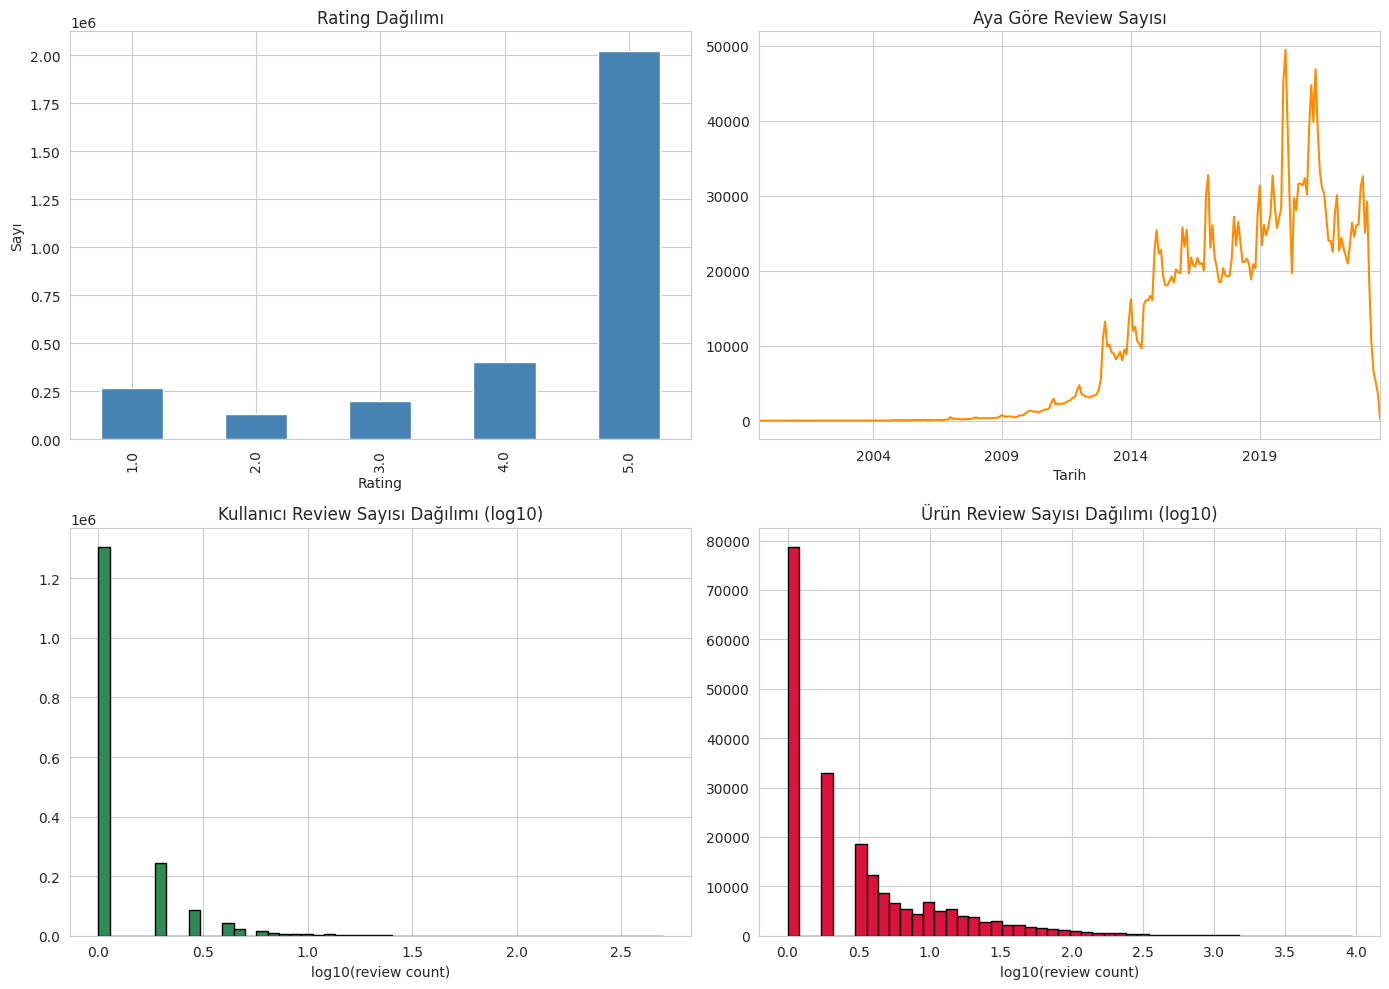


✓ Grafik kaydedildi: /content/drive/MyDrive/data-mining-hw/figures/eda_initial.png


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Rating dağılımı
rating_dist.plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Rating Dağılımı', fontsize=12)
axes[0,0].set_xlabel('Rating')
axes[0,0].set_ylabel('Sayı')

# 2. Aya göre review
monthly = df_reviews['date'].dt.to_period('M').value_counts().sort_index()
monthly.plot(ax=axes[0,1], color='darkorange')
axes[0,1].set_title('Aya Göre Review Sayısı', fontsize=12)
axes[0,1].set_xlabel('Tarih')

# 3. Kullanıcı aktivite (log-log)
axes[1,0].hist(np.log10(user_counts.values), bins=50, color='seagreen', edgecolor='black')
axes[1,0].set_title('Kullanıcı Review Sayısı Dağılımı (log10)', fontsize=12)
axes[1,0].set_xlabel('log10(review count)')

# 4. Ürün popülerlik (log)
axes[1,1].hist(np.log10(item_counts.values), bins=50, color='crimson', edgecolor='black')
axes[1,1].set_title('Ürün Review Sayısı Dağılımı (log10)', fontsize=12)
axes[1,1].set_xlabel('log10(review count)')

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/figures/eda_initial.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'\n✓ Grafik kaydedildi: {PROJECT_DIR}/figures/eda_initial.png')

## 7. Özet Bilgileri Kaydet

In [19]:
import json

summary = {
    'category': 'Musical_Instruments',
    'total_reviews': int(len(df_reviews)),
    'unique_users': int(df_reviews['user_id'].nunique()),
    'unique_items_in_reviews': int(df_reviews['parent_asin'].nunique()),
    'total_items_metadata': int(len(df_meta)),
    'date_min': str(df_reviews['date'].min().date()),
    'date_max': str(df_reviews['date'].max().date()),
    'mean_rating': float(df_reviews['rating'].mean()),
    'verified_pct': float(df_reviews['verified_purchase'].mean()),
    'users_ge_3_reviews': int((user_counts >= 3).sum()),
    'users_ge_5_reviews': int((user_counts >= 5).sum()),
    'users_ge_10_reviews': int((user_counts >= 10).sum()),
    'items_ge_3_reviews': int((item_counts >= 3).sum()),
    'items_ge_5_reviews': int((item_counts >= 5).sum()),
    'items_ge_10_reviews': int((item_counts >= 10).sum()),
    'items_with_image_pct': float(df_meta['has_image'].mean()),
    'items_with_description_pct': float((df_meta['desc_len'] > 0).mean()),
    'items_with_price_pct': float(df_meta['price_num'].notna().mean()),
    'items_with_bought_together_pct': float(df_meta['has_bought_together'].mean()),
}

with open(f'{PROJECT_DIR}/data/eda_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('=== ÖZET (sampling kararı için) ===')
print(json.dumps(summary, indent=2))
print(f'\n✓ Kaydedildi: {PROJECT_DIR}/data/eda_summary.json')

=== ÖZET (sampling kararı için) ===
{
  "category": "Musical_Instruments",
  "total_reviews": 3017439,
  "unique_users": 1762679,
  "unique_items_in_reviews": 213571,
  "total_items_metadata": 213593,
  "date_min": "1999-08-26",
  "date_max": "2023-09-12",
  "mean_rating": 4.255534246094122,
  "verified_pct": 0.9214817598632483,
  "users_ge_3_reviews": 214135,
  "users_ge_5_reviews": 84574,
  "users_ge_10_reviews": 23286,
  "items_ge_3_reviews": 102066,
  "items_ge_5_reviews": 71218,
  "items_ge_10_reviews": 42363,
  "items_with_image_pct": 0.9995037290547911,
  "items_with_description_pct": 0.7150702504295553,
  "items_with_price_pct": 0.39738193667395466,
  "items_with_bought_together_pct": 0.0
}

✓ Kaydedildi: /content/drive/MyDrive/data-mining-hw/data/eda_summary.json
